# Сигнальный и ML-слой для трансграничных переводов

## От открытых курсов ЦБ до проверяемого сигнала



Здесь:

1. загружаем и проверяем официальные курсы;
2. делаем EDA;
3. строим простые сигналы без ML;
4. определяем, что такое «хороший момент»;
5. создаём признаки без информации из будущего;
6. сравниваем Logistic Regression, HistGradientBoosting и Extra Trees;
7. проверяем модели методом walk-forward;
8. учитываем асимметричную цену ошибки;?
9. формируем финальную таблицу сигналов и локальное объяснение;
10. запускаем проверки на утечку будущего.

Главный принцип: **сигнал на дату T использует только то, что было доступно на дату T**.

## 0. Сначала фиксируем экономический смысл


ЦБ публикует курс в представлении:

```text
рублей за одну единицу валюты получателя
```

Например:

- `1 TJS = 8,50 RUB` — сомони дороже;
- `1 TJS = 8,00 RUB` — сомони дешевле, клиент получит больше сомони за те же рубли.

Поэтому в техническом ряду мы ищем **минимум RUB за валюту**, но для клиента это **максимум валюты получателя за один рубль**. Это один и тот же выгодный момент, просто курс записан с разных сторон.

## 1. Библиотеки и настройки

In [27]:
import importlib.util
import json
import math
import random
import subprocess
import sys
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from bisect import bisect_right
from pathlib import Path

if importlib.util.find_spec("holidays") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "holidays"])

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
print("Среда готова")

Среда готова


## 2. Конфигурация эксперимента
- горизонт — 5 следующих публикаций;
- допустимое отклонение от локального минимума — 25 б.п. = 0,25%;
- ложный пуш в 4 раза дороже пропущенного момента;
- после сигнала пропускаем одно обновление;
- модель должна давать управляемую частоту, а не писать каждый день.

In [28]:
RECIPIENT_CURRENCIES = ("TJS", "UZS", "KGS", "AMD", "KZT")
CONTEXT_CURRENCIES = ("USD", "EUR", "CNY")
ALL_CURRENCIES = RECIPIENT_CURRENCIES + CONTEXT_CURRENCIES

HORIZON = 5
TOLERANCE_BPS = 25
FALSE_POSITIVE_COST = 4.0
COOLDOWN_UPDATES = 1
MIN_WEEKLY_RATE = 1.4
STRONG_MARGIN = 0.15

CBR_CURRENCY_IDS = {
    "TJS": "R01670", "UZS": "R01717", "KGS": "R01370", "AMD": "R01060",
    "KZT": "R01335", "USD": "R01235", "EUR": "R01239", "CNY": "R01375",
}
CORRIDOR_COUNTRIES = {"TJS": "TJ", "UZS": "UZ", "KGS": "KG", "AMD": "AM", "KZT": "KZ"}

CONFIG = {
    "horizon_publications": HORIZON,
    "tolerance_bps": TOLERANCE_BPS,
    "false_positive_cost": FALSE_POSITIVE_COST,
    "cooldown_updates": COOLDOWN_UPDATES,
    "strong_margin": STRONG_MARGIN,
}
CONFIG

{'horizon_publications': 5,
 'tolerance_bps': 25,
 'false_positive_cost': 4.0,
 'cooldown_updates': 1,
 'strong_margin': 0.15}

## 3. Загрузка данных

In [29]:
def parse_number(text):
    return float(str(text).strip().replace(" ", "").replace(",", "."))

def download_currency(currency, start="2010-01-01", end="2026-08-29"):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    rows = []
    chunk_start = start
    while chunk_start <= end:
        chunk_end = min(pd.Timestamp(f"{chunk_start.year + 2}-12-31"), end)
        params = urllib.parse.urlencode({
            "date_req1": chunk_start.strftime("%d/%m/%Y"),
            "date_req2": chunk_end.strftime("%d/%m/%Y"),
            "VAL_NM_RQ": CBR_CURRENCY_IDS[currency],
        })
        url = f"https://www.cbr.ru/scripts/XML_dynamic.asp?{params}"
        request = urllib.request.Request(url, headers={"User-Agent": "fx-signal-kaggle/1.0"})
        with urllib.request.urlopen(request, timeout=120) as response:
            root = ET.fromstring(response.read())
        for node in root.findall("Record"):
            current_date = pd.to_datetime(node.attrib["Date"], format="%d.%m.%Y")
            nominal = int(parse_number(node.findtext("Nominal", "1")))
            value_rub = parse_number(node.findtext("Value", "0"))
            rows.append({
                "effective_date": current_date,
                "available_date": current_date,
                "currency": currency,
                "corridor": f"RUB_{currency}",
                "nominal": nominal,
                "value_rub": value_rub,
                "rub_per_unit": value_rub / nominal,
            })
        chunk_start = pd.Timestamp(f"{chunk_end.year + 1}-01-01")
    return pd.DataFrame(rows).drop_duplicates(["available_date", "currency"])


def find_rates_file():
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(kaggle_input.rglob("rates.csv"))
    candidates.extend([Path("rates.csv"), Path("data/rates.csv"), Path("../data/rates.csv")])
    return next((path for path in candidates if path.exists()), None)


def load_rates():
    path = find_rates_file()
    if path is not None:
        print(f"Читаем готовую выгрузку: {path}")
        return pd.read_csv(path, parse_dates=["effective_date", "available_date"])

    print("rates.csv не найден — скачиваем открытые ряды ЦБ РФ")
    parts = [download_currency(currency) for currency in ALL_CURRENCIES]
    result = pd.concat(parts, ignore_index=True)
    output = Path("/kaggle/working/rates.csv") if Path("/kaggle/working").exists() else Path("rates.csv")
    result.to_csv(output, index=False)
    print(f"Сохранено: {output}")
    return result


rates = load_rates().sort_values(["currency", "available_date"]).reset_index(drop=True)
rates["corridor"] = "RUB_" + rates["currency"]
rates.head()

Читаем готовую выгрузку: rates.csv


,effective_date,available_date,currency,corridor,nominal,value_rub,rub_per_unit
0,2010-01-12,2010-01-12,AMD,RUB_AMD,1000,77.9042,0.077904
1,2010-01-13,2010-01-13,AMD,RUB_AMD,1000,77.8209,0.077821
2,2010-01-14,2010-01-14,AMD,RUB_AMD,1000,78.4670,0.078467
3,2010-01-15,2010-01-15,AMD,RUB_AMD,1000,77.9600,0.077960
4,2010-01-16,2010-01-16,AMD,RUB_AMD,1000,78.2536,0.078254


## 4. Проверка качества данных

In [30]:
rates["normalization_error"] = (rates["value_rub"] / rates["nominal"] - rates["rub_per_unit"]).abs()

quality = (
    rates.groupby("currency")
    .agg(
        observations=("available_date", "size"),
        start=("available_date", "min"),
        end=("available_date", "max"),
        unique_dates=("available_date", "nunique"),
        min_rate=("rub_per_unit", "min"),
        max_rate=("rub_per_unit", "max"),
        max_normalization_error=("normalization_error", "max"),
    )
    .reset_index()
)
quality["duplicate_dates"] = quality["observations"] - quality["unique_dates"]

display(Markdown(
    f"**Количество данных** {len(rates):,} строк, "
    f"период {rates.available_date.min().date()} — {rates.available_date.max().date()}, "
    f"валютных рядов: {rates.currency.nunique()}."
))
display(quality)

**Количество данных** 32,916 строк, период 2010-01-01 — 2026-08-29, валютных рядов: 8.

,currency,observations,start,end,unique_dates,min_rate,max_rate,max_normalization_error,duplicate_dates
0,AMD,4114,2010-01-12,2026-08-29,4114,0.071799,0.278846,9.714451e-17,0
1,CNY,4115,2010-01-01,2026-08-29,4115,4.197720,19.041500,1.776357e-15,0
2,EUR,4115,2010-01-01,2026-08-29,4115,37.420600,132.958100,0.000000e+00,0
3,KGS,4114,2010-01-12,2026-08-29,4114,0.584369,1.262420,2.220446e-16,0
4,KZT,4115,2010-01-01,2026-08-29,4115,0.112176,0.377368,9.714451e-17,0
5,TJS,4114,2010-01-12,2026-08-29,4114,4.729820,12.965000,1.776357e-15,0
6,USD,4115,2010-01-01,2026-08-29,4115,27.262500,120.378500,0.000000e+00,0
7,UZS,4114,2010-01-12,2026-08-29,4114,0.004737,0.029822,9.974660e-17,0


## 5. EDA: что происходит с курсами

Абсолютные уровни валют сравнивать нельзя: один сомони и один сум стоят по-разному. Поэтому каждый ряд приводим к индексу 100 на первой дате.

Если индекс растёт — валюта получателя дорожает в рублях. Если падает — за те же рубли клиент может получить больше валюты.

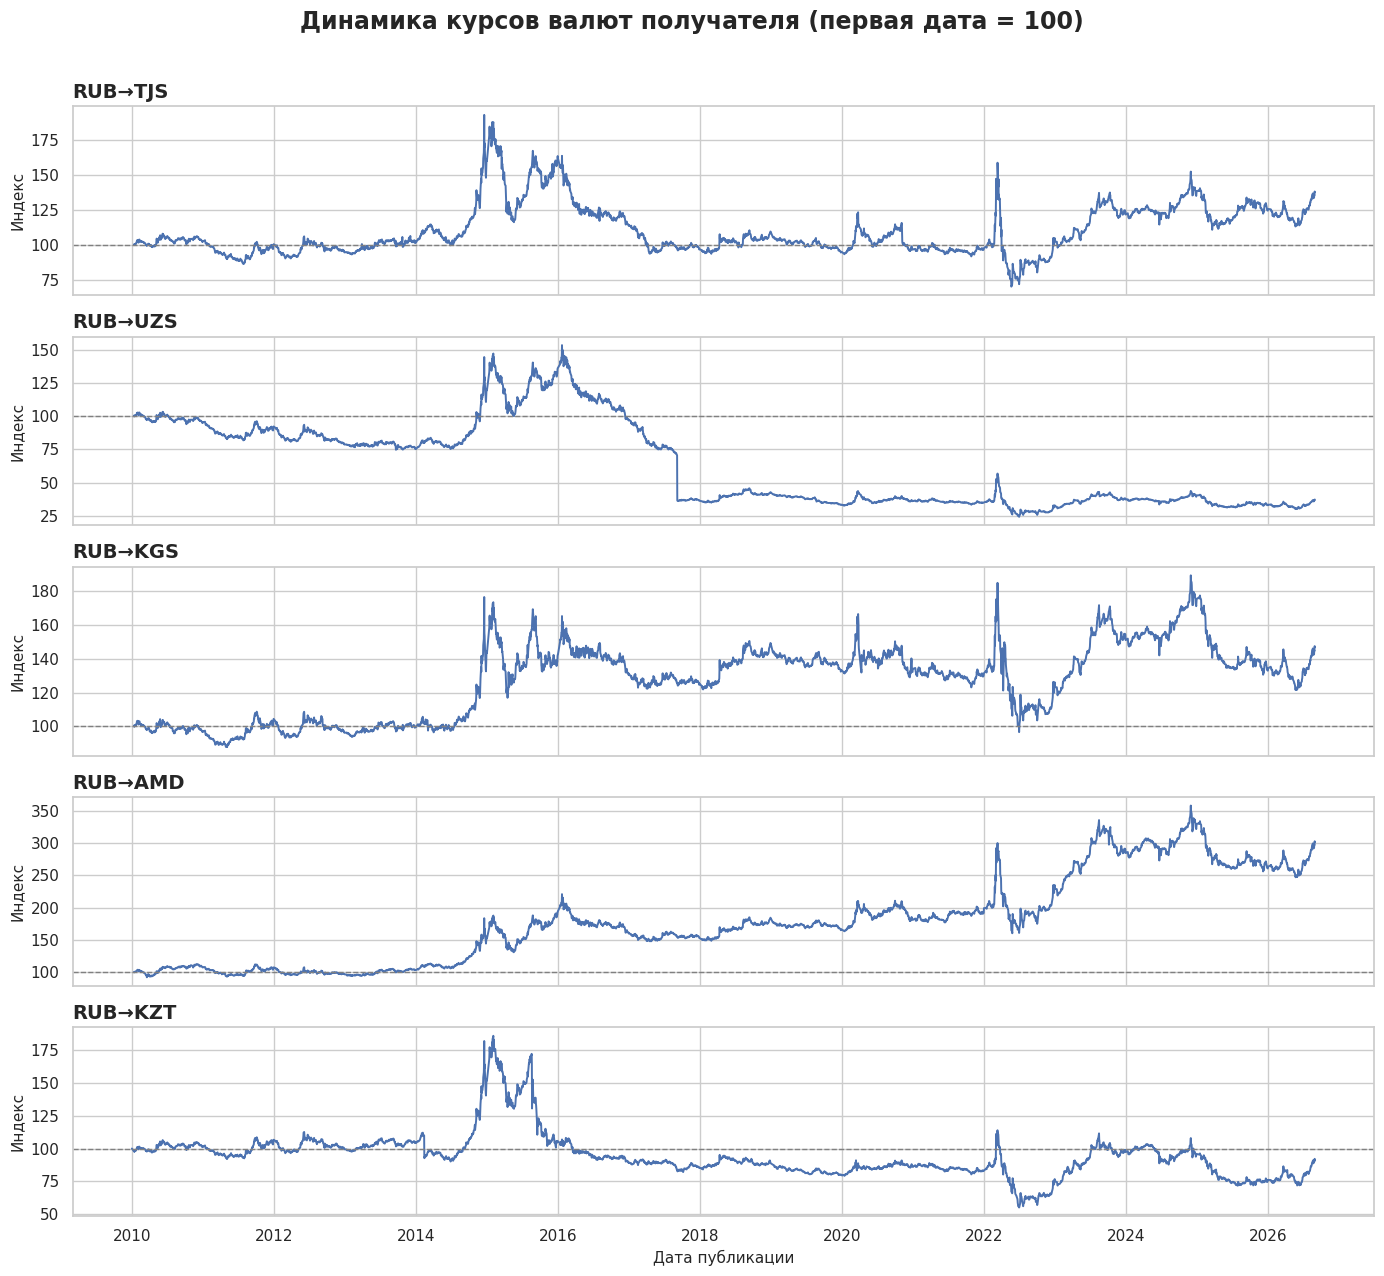

In [31]:
recipients = rates[rates.currency.isin(RECIPIENT_CURRENCIES)].copy()
recipients["index_100"] = recipients.groupby("currency")["rub_per_unit"].transform(lambda s: s / s.iloc[0] * 100)

fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
for ax, currency in zip(axes, RECIPIENT_CURRENCIES):
    current = recipients[recipients.currency == currency]
    ax.plot(current.available_date, current.index_100, linewidth=1.4)
    ax.axhline(100, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"RUB→{currency}", loc="left", fontweight="bold")
    ax.set_ylabel("Индекс")
axes[-1].set_xlabel("Дата публикации")
fig.suptitle("Динамика курсов валют получателя (первая дата = 100)", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

,median,p95,p99
currency,,,
TJS,0.458,2.361,5.031
UZS,0.467,2.180,4.402
KGS,0.455,2.302,4.755
AMD,0.465,2.154,4.189
KZT,0.422,2.100,4.252


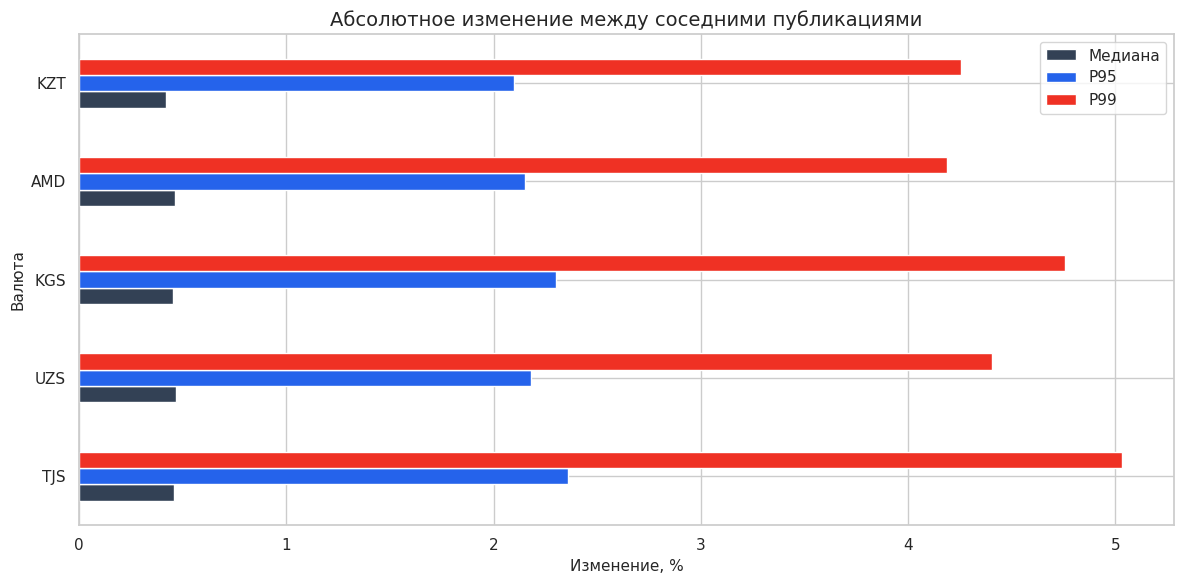

In [32]:
rates["return_pct"] = rates.groupby("currency")["rub_per_unit"].pct_change() * 100
return_stats = (
    rates[rates.currency.isin(RECIPIENT_CURRENCIES)]
    .assign(abs_return=lambda x: x.return_pct.abs())
    .groupby("currency")["abs_return"]
    .quantile([0.50, 0.95, 0.99])
    .unstack()
    .rename(columns={0.50: "median", 0.95: "p95", 0.99: "p99"})
    .reindex(RECIPIENT_CURRENCIES)
)
display(return_stats.round(3))

return_stats.plot(kind="barh", figsize=(12, 6), color=["#334155", "#2563EB", "#EF3124"])
plt.title("Абсолютное изменение между соседними публикациями")
plt.xlabel("Изменение, %")
plt.ylabel("Валюта")
plt.legend(["Медиана", "P95", "P99"])
plt.tight_layout()
plt.show()

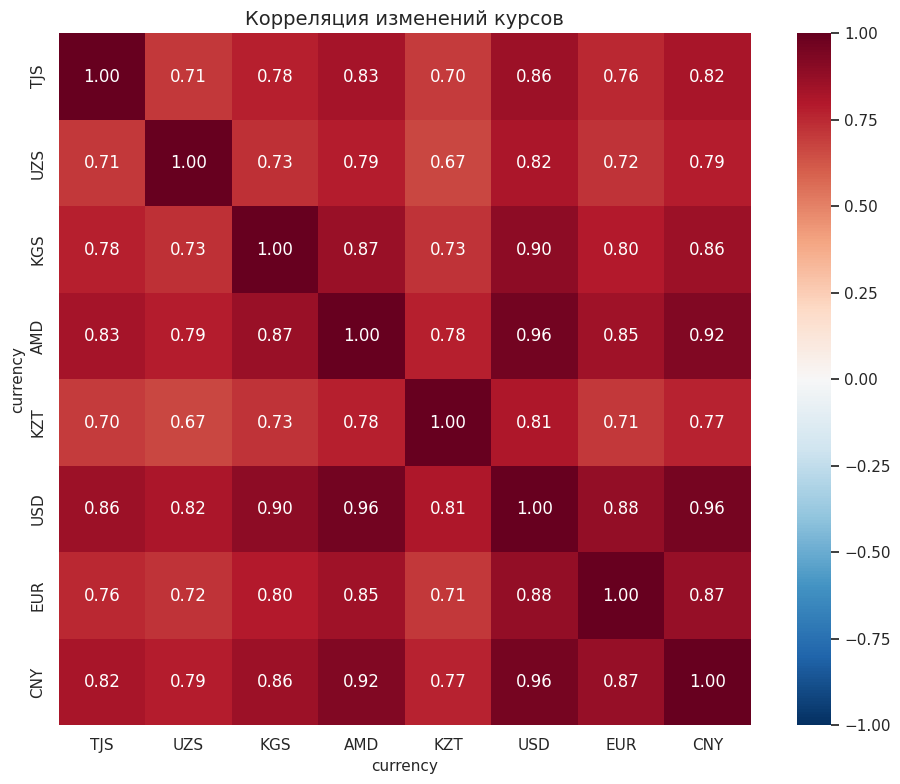

**Что видим** валюты сильно связаны через общий рублёвый фактор. Поэтому USD, EUR и CNY полезно оставить как контекст, но случайно перемешивать даты нельзя.

In [54]:
return_panel = (
    rates.pivot(index="available_date", columns="currency", values="rub_per_unit")
    .sort_index()
    .pct_change(fill_method=None)
)
correlation = return_panel[list(ALL_CURRENCIES)].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Корреляция изменений курсов")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Что видим** валюты сильно связаны через общий рублёвый фактор. "
    "Поэтому USD, EUR и CNY полезно оставить как контекст, но случайно перемешивать даты нельзя."
))

## 6. Сначала сигналы без ML

правила:

- **level** — курс находится в нижних 20% последних 60 публикаций;
- **momentum** — курс снижается три публикации подряд;
- **stability** — курс низкий, продолжает снижаться, но последнее движение уже небольшое;
- **reversal** — курс был у минимума и начал от него расти: выгодное окно может закрываться.

Здесь ничего не обучается. Это человеческие гипотезы, которые мы обязаны проверить на истории. Их польза — понятность и честный baseline для ML.

И ещё один важный момент: сообщения проверяются по-разному. Для `level/momentum/stability` проверяем, что после пуша курс не стал заметно выгоднее. Для `reversal` проверяем, что курс действительно продолжил расти — то есть окно действительно закрывалось.

In [34]:
def trailing_rank(series, window):
    return series.rolling(window).apply(lambda values: np.mean(values <= values[-1]), raw=True)


def add_historical_target(frame, horizon=HORIZON, tolerance_bps=TOLERANCE_BPS):
    result = frame.copy()
    window = 2 * horizon + 1
    local_min = result.rub_per_unit.rolling(window, center=True).min()
    local_mean = result.rub_per_unit.rolling(window, center=True).mean()
    result["target"] = (result.rub_per_unit <= local_min * (1 + tolerance_bps / 10_000)).where(local_min.notna())
    result["benefit_bps"] = (local_mean / result.rub_per_unit - 1) * 10_000

    future = pd.concat(
        [result.rub_per_unit.shift(-step) for step in range(1, horizon + 1)], axis=1
    )
    complete_future = future.notna().all(axis=1)
    result["good_now_hit"] = (
        future.min(axis=1) >= result.rub_per_unit * (1 - tolerance_bps / 10_000)
    ).where(complete_future)
    result["window_closing_hit"] = (
        future.max(axis=1) >= result.rub_per_unit * (1 + tolerance_bps / 10_000)
    ).where(complete_future)
    return result


def simple_signal_frame(rates, corridor):
    current = rates[rates.corridor == corridor].sort_values("available_date").copy()
    rate = current.rub_per_unit
    current["return_1_bps"] = rate.pct_change(1) * 10_000
    current["return_3_bps"] = rate.pct_change(3) * 10_000
    current["rank_60"] = trailing_rank(rate, 60)

    down = rate.diff().lt(0)
    groups = down.ne(down.shift()).cumsum()
    current["down_streak"] = down.groupby(groups).cumsum().where(down, 0)

    prior_min = rate.shift(1).rolling(20).min()
    previous_near_min = rate.shift(1) <= prior_min * 1.001
    bounce_bps = (rate / prior_min - 1) * 10_000

    current["level"] = current.rank_60 <= 0.20
    current["momentum"] = current.down_streak >= 3
    current["stability"] = current.level & current.return_1_bps.abs().le(20) & current.return_3_bps.lt(0)
    current["reversal"] = previous_near_min & bounce_bps.ge(40)
    return add_historical_target(current)


def cooldown_indices(mask, cooldown=COOLDOWN_UPDATES):
    selected = []
    last = -cooldown - 1
    for index, value in enumerate(np.asarray(mask, dtype=bool)):
        if value and index - last > cooldown:
            selected.append(index)
            last = index
    return selected


def evaluate_simple_rules(rates):
    rows = []
    for currency in RECIPIENT_CURRENCIES:
        corridor = f"RUB_{currency}"
        source = simple_signal_frame(rates, corridor)
        for indicator in ("level", "momentum", "stability", "reversal"):
            truth_column = "window_closing_hit" if indicator == "reversal" else "good_now_hit"
            frame = source.dropna(subset=[truth_column]).reset_index(drop=True)
            baseline = frame[truth_column].mean()
            span_weeks = max((frame.available_date.iloc[-1] - frame.available_date.iloc[0]).days / 7, 1)
            selected = cooldown_indices(frame[indicator])
            hit_rate = frame.loc[selected, truth_column].mean() if selected else 0.0
            rows.append({
                "corridor": corridor,
                "indicator": indicator,
                "truth_metric": truth_column,
                "signals": len(selected),
                "hit_rate": hit_rate,
                "baseline_hit_rate": baseline,
                "lift": hit_rate / baseline if baseline and selected else 0.0,
                "mean_benefit_bps": frame.loc[selected, "benefit_bps"].mean() if selected else 0.0,
                "signals_per_week": len(selected) / span_weeks,
            })
    return pd.DataFrame(rows)

,corridor,indicator,truth_metric,signals,hit_rate,baseline_hit_rate,lift,mean_benefit_bps,signals_per_week
0,RUB_TJS,level,good_now_hit,678,0.323,0.366,0.882,38.297,0.782
1,RUB_TJS,momentum,good_now_hit,353,0.314,0.366,0.859,73.729,0.407
2,RUB_TJS,stability,good_now_hit,178,0.303,0.366,0.828,30.449,0.205
3,RUB_TJS,reversal,window_closing_hit,160,0.681,0.649,1.050,12.541,0.185
4,RUB_UZS,level,good_now_hit,791,0.300,0.346,0.867,31.003,0.913
5,RUB_UZS,momentum,good_now_hit,391,0.307,0.346,0.888,84.917,0.451
6,RUB_UZS,stability,good_now_hit,229,0.332,0.346,0.960,29.103,0.264
7,RUB_UZS,reversal,window_closing_hit,153,0.693,0.627,1.105,15.312,0.177
8,RUB_KGS,level,good_now_hit,621,0.351,0.363,0.967,41.195,0.717
9,RUB_KGS,momentum,good_now_hit,369,0.314,0.363,0.866,85.646,0.426


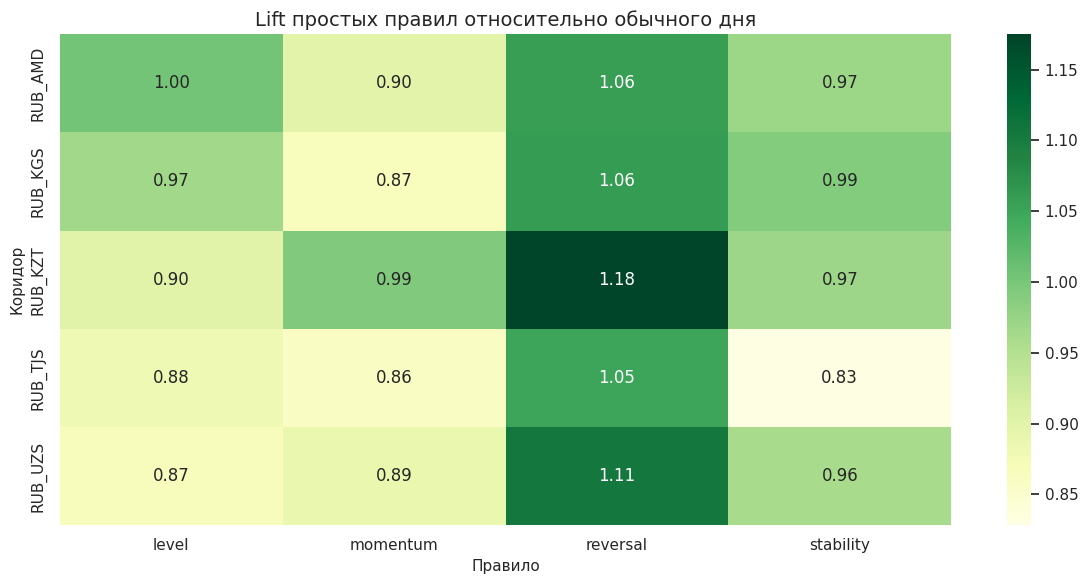

**Результат:** простые правила объяснимы, но работают нестабильно. Это и стало причиной добавить ML, который объединяет признаки и учитывает их взаимодействия.

In [35]:
simple_results = evaluate_simple_rules(rates)
display(simple_results.round(3))

simple_pivot = simple_results.pivot(index="corridor", columns="indicator", values="lift")
sns.heatmap(simple_pivot, annot=True, fmt=".2f", cmap="YlGn", center=1.0)
plt.title("Lift простых правил относительно обычного дня")
plt.xlabel("Правило")
plt.ylabel("Коридор")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Результат:** простые правила объяснимы, но работают нестабильно. "
    "Это и стало причиной добавить ML, который объединяет признаки и учитывает их взаимодействия."
))

## 7. Что является целью ML

Для каждой исторической даты создаём ответ:

```text
target = 1 — дата оказалась около локального минимума;
target = 0 — не оказалась.
```

Дата считается около минимума, если её курс находится не дальше 25 б.п. от минимального курса в окне ±5 публикаций.

**Важный момент:** будущие пять публикаций здесь используются только для создания исторического правильного ответа. В признаках будущего нет. Последние пять дат вообще нельзя размечать — их будущее ещё неизвестно.

Для продуктовой проверки можно дополнительно использовать forward-only определение: не стал ли курс заметно выгоднее после пуша. На QA-сессии стоит подтвердить, какую формулировку кейсодатель считает основной.

In [36]:
example_target = simple_signal_frame(rates, "RUB_TJS")[
    ["available_date", "rub_per_unit", "target", "benefit_bps"]
].dropna()
display(example_target)
display(Markdown(
    f"Доля положительного класса для RUB→TJS: **{example_target.target.mean():.1%}** в показанном фрагменте. "
    "По всей истории долю считаем ниже при построении датасета."
))

,available_date,rub_per_unit,target,benefit_bps
20578,2010-01-19,6.76982,False,9.835094
20579,2010-01-20,6.75308,False,62.125188
20580,2010-01-21,6.79312,False,31.095633
20581,2010-01-22,6.80528,False,35.600699
20582,2010-01-23,6.80635,False,64.913981
...,...,...,...,...
24677,2026-08-18,9.18143,False,-144.816023
24678,2026-08-19,9.19991,False,-144.639755
24679,2026-08-20,9.19611,False,-119.748261
24680,2026-08-21,9.00931,False,117.695422


Доля положительного класса для RUB→TJS: **11.2%** в показанном фрагменте. По всей истории долю считаем ниже при построении датасета.

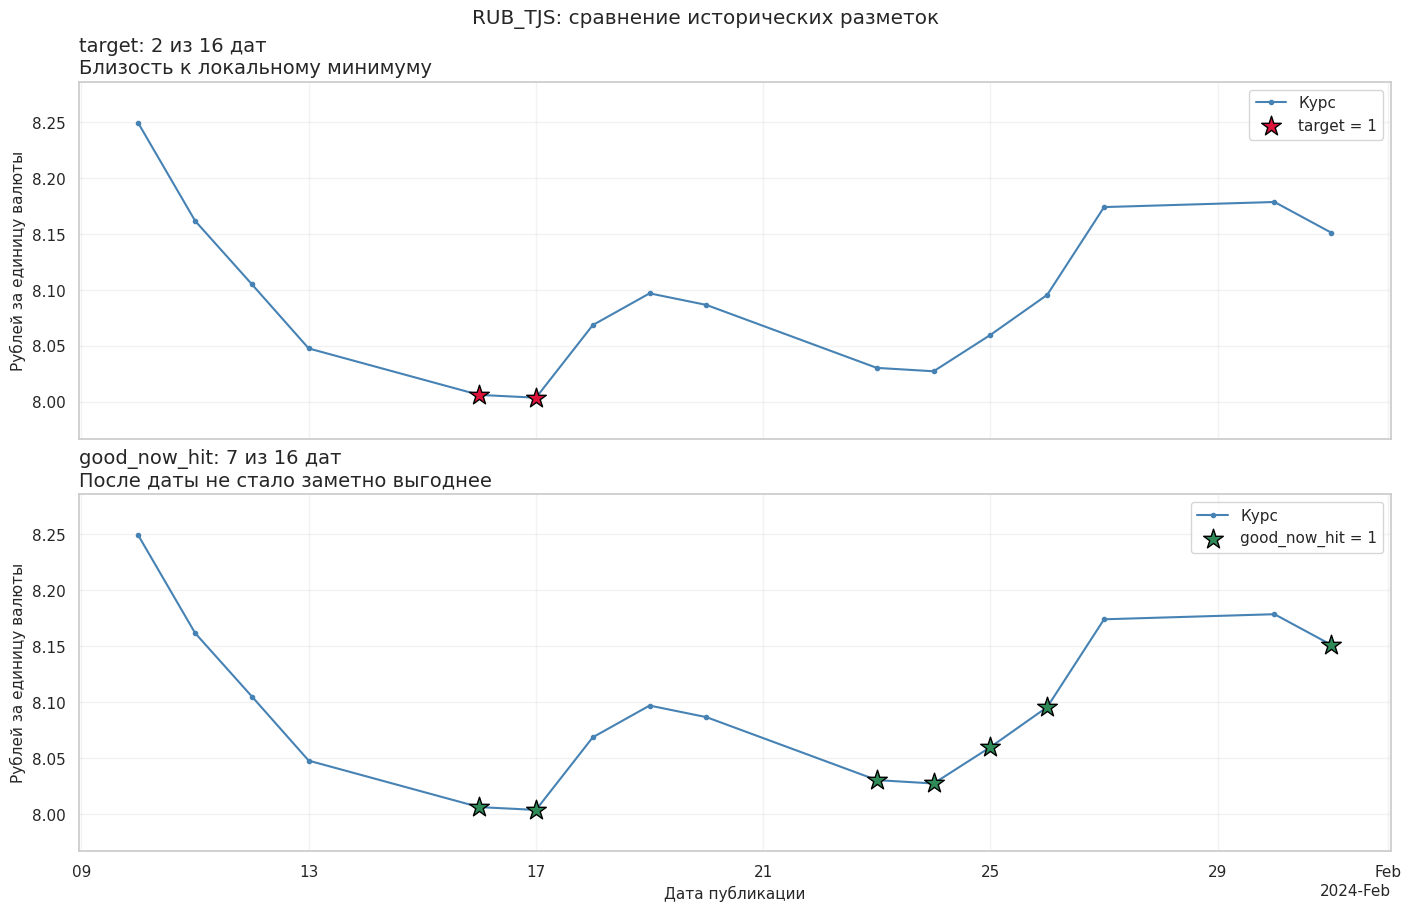

In [53]:
corridor = "RUB_TJS"
start_date = pd.Timestamp("2024-01-01")
end_date = start_date + pd.DateOffset(months=1)  # можно months=2

# Сначала размечаем ПОЛНУЮ историю
all_labels = simple_signal_frame(rates, corridor)

# Только потом обрезаем период для картинки
plot_data = all_labels.loc[
    (all_labels["available_date"] >= start_date)
    & (all_labels["available_date"] < end_date)
].dropna(subset=["target", "good_now_hit"]).sort_values("available_date")

if plot_data.empty:
    raise ValueError("В выбранном периоде нет размеченных данных")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

settings = [
    ("target", "crimson", "Близость к локальному минимуму"),
    ("good_now_hit", "seagreen", "После даты не стало заметно выгоднее")
]

for ax, (column, color, description) in zip(axes, settings):
    selected = plot_data.loc[plot_data[column].eq(1)]

    ax.plot(
        plot_data["available_date"],
        plot_data["rub_per_unit"],
        color="steelblue",
        marker="o",
        markersize=3,
        label="Курс"
    )

    ax.scatter(
        selected["available_date"],
        selected["rub_per_unit"],
        marker="*",
        s=220,
        color=color,
        edgecolor="black",
        zorder=5,
        label=f"{column} = 1"
    )

    ax.set_title(
        f"{column}: {len(selected)} из {len(plot_data)} дат\n"
        f"{description}",
        loc="left"
    )
    ax.set_ylabel("Рублей за единицу валюты")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.margins(y=0.15)

locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(locator)
)
axes[-1].set_xlabel("Дата публикации")

fig.suptitle(f"{corridor}: сравнение исторических разметок")
plt.show()

## 8. Признаки для модели

Мы строим 36 признаков:

- изменения за 1/3/5/10/20 публикаций;
- волатильность за 5 и 20 публикаций;
- положение курса в диапазоне за 20/60/120 публикаций;
- расстояние до локальных минимумов и максимума;
- длина серий роста и снижения, ускорение;
- сезонность месяца;
- движение USD/EUR/CNY;
- расстояние до праздников России и страны получателя.

Все скользящие показатели смотрят только назад. Контекстные валюты присоединяются по последней уже доступной дате.

In [38]:
FEATURE_NAMES = (
    "return_1_bps", "return_3_bps", "return_5_bps", "return_10_bps", "return_20_bps",
    "volatility_5_bps", "volatility_20_bps", "rank_20", "rank_60", "rank_120",
    "distance_min_20_bps", "distance_min_60_bps", "distance_max_20_bps",
    "down_streak", "up_streak", "acceleration_bps", "month_sin", "month_cos",
    "usd_return_1_bps", "usd_return_5_bps", "usd_return_20_bps", "usd_volatility_20_bps",
    "eur_return_1_bps", "eur_return_5_bps", "eur_return_20_bps", "eur_volatility_20_bps",
    "cny_return_1_bps", "cny_return_5_bps", "cny_return_20_bps", "cny_volatility_20_bps",
    "recipient_days_to_holiday_30", "recipient_days_since_holiday_30",
    "recipient_preholiday_7", "recipient_postholiday_3",
    "russia_days_to_holiday_30", "russia_preholiday_7",
)


def streak(values, direction):
    result = np.zeros(len(values), dtype=float)
    for index in range(1, len(values)):
        condition = values[index] < values[index - 1] if direction == "down" else values[index] > values[index - 1]
        result[index] = min(result[index - 1] + 1, 20) if condition else 0
    return result


def holiday_features(dates, country):
    years = range(dates.min().year - 1, dates.max().year + 2)
    calendar = sorted(holidays.country_holidays(country, years=list(years)).keys())
    ordinal = np.asarray([day.toordinal() for day in calendar])
    to_holiday, since_holiday = [], []
    for timestamp in dates:
        value = timestamp.date().toordinal()
        position = np.searchsorted(ordinal, value, side="right")
        previous = ordinal[position - 1] if position else value
        following = ordinal[position] if position < len(ordinal) else value
        to_holiday.append(min(following - value, 30))
        since_holiday.append(min(value - previous, 30))
    return np.asarray(to_holiday), np.asarray(since_holiday)


def context_feature_table(rates, currency):
    frame = rates[rates.currency == currency].sort_values("available_date")[["available_date", "rub_per_unit"]].copy()
    prefix = currency.lower()
    frame[f"{prefix}_return_1_bps"] = frame.rub_per_unit.pct_change(1) * 10_000
    frame[f"{prefix}_return_5_bps"] = frame.rub_per_unit.pct_change(5) * 10_000
    frame[f"{prefix}_return_20_bps"] = frame.rub_per_unit.pct_change(20) * 10_000
    one_day = frame.rub_per_unit.pct_change(1) * 10_000
    frame[f"{prefix}_volatility_20_bps"] = one_day.rolling(20).std(ddof=0)
    return frame.drop(columns="rub_per_unit")


def build_feature_table(rates, corridor, horizon=HORIZON):
    frame = rates[rates.corridor == corridor].sort_values("available_date")[[
        "available_date", "currency", "corridor", "rub_per_unit"
    ]].copy().reset_index(drop=True)
    value = frame.rub_per_unit
    one_day = value.pct_change(1) * 10_000

    for lag in (1, 3, 5, 10, 20):
        frame[f"return_{lag}_bps"] = value.pct_change(lag) * 10_000
    frame["volatility_5_bps"] = one_day.rolling(5).std(ddof=0)
    frame["volatility_20_bps"] = one_day.rolling(20).std(ddof=0)
    for window in (20, 60, 120):
        frame[f"rank_{window}"] = trailing_rank(value, window)
    frame["distance_min_20_bps"] = (value / value.rolling(20).min() - 1) * 10_000
    frame["distance_min_60_bps"] = (value / value.rolling(60).min() - 1) * 10_000
    frame["distance_max_20_bps"] = (value / value.rolling(20).max() - 1) * 10_000
    frame["down_streak"] = streak(value.to_numpy(), "down")
    frame["up_streak"] = streak(value.to_numpy(), "up")
    frame["acceleration_bps"] = one_day - one_day.shift(1)

    angle = 2 * np.pi * (frame.available_date.dt.month - 1) / 12
    frame["month_sin"] = np.sin(angle)
    frame["month_cos"] = np.cos(angle)

    for context_currency in CONTEXT_CURRENCIES:
        context = context_feature_table(rates, context_currency)
        frame = pd.merge_asof(
            frame.sort_values("available_date"), context.sort_values("available_date"),
            on="available_date", direction="backward"
        )

    recipient_country = CORRIDOR_COUNTRIES[corridor.replace("RUB_", "")]
    recipient_to, recipient_since = holiday_features(frame.available_date, recipient_country)
    russia_to, russia_since = holiday_features(frame.available_date, "RU")
    frame["recipient_days_to_holiday_30"] = recipient_to / 30
    frame["recipient_days_since_holiday_30"] = recipient_since / 30
    frame["recipient_preholiday_7"] = ((recipient_to > 0) & (recipient_to <= 7)).astype(float)
    frame["recipient_postholiday_3"] = (recipient_since <= 3).astype(float)
    frame["russia_days_to_holiday_30"] = russia_to / 30
    frame["russia_preholiday_7"] = ((russia_to > 0) & (russia_to <= 7)).astype(float)

    frame = add_historical_target(frame, horizon=horizon)
    return frame

In [55]:
feature_tables = {
    f"RUB_{currency}": build_feature_table(rates, f"RUB_{currency}")
    for currency in RECIPIENT_CURRENCIES
}
datasets = {
    corridor: table.dropna(subset=list(FEATURE_NAMES) + ["target"]).reset_index(drop=True)
    for corridor, table in feature_tables.items()
}

dataset_summary = pd.DataFrame([
    {
        "corridor": corridor,
        "rows_for_ml": len(table),
        "positive_class_share": table.target.mean(),
        "first_date": table.available_date.min(),
        "last_labeled_date": table.available_date.max(),
    }
    for corridor, table in datasets.items()
])
display(dataset_summary)

display(Markdown(
    f"**готово:** у каждой даты теперь {len(FEATURE_NAMES)} признаков и один исторический ответ. "
    "Последние даты без известного будущего в обучение не попали."
))

,corridor,rows_for_ml,positive_class_share,first_date,last_labeled_date
0,RUB_TJS,3990,0.111779,2010-07-03,2026-08-22
1,RUB_UZS,3990,0.113784,2010-07-03,2026-08-22
2,RUB_KGS,3990,0.126566,2010-07-03,2026-08-22
3,RUB_AMD,3990,0.109273,2010-07-03,2026-08-22
4,RUB_KZT,3991,0.123779,2010-07-02,2026-08-22


**готово:** у каждой даты теперь 36 признаков и один исторический ответ. Последние даты без известного будущего в обучение не попали.

## 9. Какие модели сравниваем

ML-слой. Все модели получают абсолютно одинаковые признаки и одинаковые временные отрезки.

1. **Logistic Regression** — простой и хорошо объяснимый baseline.
2. **HistGradientBoosting** — последовательность небольших деревьев, умеющая находить нелинейные сочетания.
3. **Extra Trees** — ансамбль независимых случайных деревьев.

Модель обучается выдавать вероятность `P(target=1)`. Внутри обучение минимизирует log loss. Но пуш мы оцениваем не по log loss, а по hit rate, lift, выгоде, частоте, кучности и качеству вероятностей.

In [40]:
MODEL_NAMES = ("logistic", "hist_gradient_boosting", "extra_trees")


def build_model(name):
    if name == "logistic":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
        )
    if name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=60,
            max_leaf_nodes=7,
            min_samples_leaf=20,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=SEED,
        )
    if name == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=60,
            max_depth=8,
            min_samples_leaf=10,
            max_features=0.8,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        )
    raise ValueError(f"Неизвестная модель: {name}")


[build_model(name) for name in MODEL_NAMES]

[Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 HistGradientBoostingClassifier(class_weight='balanced', l2_regularization=1.0,
                                learning_rate=0.08, max_iter=60,
                                max_leaf_nodes=7, random_state=42),
 ExtraTreesClassifier(class_weight='balanced', max_depth=8, max_features=0.8,
                      min_samples_leaf=10, n_estimators=60, n_jobs=-1,
                      random_state=42)]

## 10. Как считаем ошибку и выбираем порог

Три разных уровня ошибки:

1. **Log loss** — по нему модель учится выдавать вероятности.
2. **Brier score** — проверяет, насколько вероятности похожи на реальность: `mean((p-y)²)`.
3. **Бизнес-ошибка порога** — ложный пуш дороже пропущенного момента:

```text
cost = (4 × FP + 1 × FN) / число дат
```

Где FP — мы отправили плохой сигнал, FN — пропустили хороший момент. Порог перебирается только на прошлом валидационном участке. Также мы не разрешаем модели генерировать больше двух сигналов в неделю.

In [41]:
def select_with_cooldown(probabilities, threshold, cooldown=COOLDOWN_UPDATES):
    selected = []
    last = -cooldown - 1
    for index, probability in enumerate(probabilities):
        if probability >= threshold and index - last > cooldown:
            selected.append(index)
            last = index
    return selected


def choose_threshold(probabilities, labels, dates, false_positive_cost=FALSE_POSITIVE_COST,
                     cooldown=COOLDOWN_UPDATES, min_weekly_rate=MIN_WEEKLY_RATE):
    span_weeks = max((pd.Timestamp(dates[-1]) - pd.Timestamp(dates[0])).days / 7, 1)
    valid_candidates = []
    fallbacks = []
    for threshold in np.arange(0.10, 0.951, 0.025):
        selected = select_with_cooldown(probabilities, threshold, cooldown)
        rate = len(selected) / span_weeks
        if not selected or rate > 2.0:
            continue
        selected_set = set(selected)
        false_positives = sum(labels[index] == 0 for index in selected)
        false_negatives = sum(labels[index] == 1 for index in range(len(labels)) if index not in selected_set)
        cost = (false_positive_cost * false_positives + false_negatives) / len(labels)
        fallbacks.append((abs(rate - min_weekly_rate), cost, float(threshold)))
        if rate >= min_weekly_rate:
            valid_candidates.append((cost, float(threshold)))
    if valid_candidates:
        return min(valid_candidates)[1]
    return min(fallbacks)[2] if fallbacks else 0.95


def timing_indices(probabilities, threshold, strong_margin=STRONG_MARGIN,
                   cooldown=COOLDOWN_UPDATES):
    strong_threshold = min(threshold + strong_margin, 0.95)
    candidates = []
    for index, probability in enumerate(probabilities):
        if probability >= strong_threshold:
            candidates.append((index, "fast"))
        elif index > 0 and probability >= threshold and probabilities[index - 1] >= threshold:
            candidates.append((index, "confirmed"))

    selected = []
    for index, speed in candidates:
        if not selected or index - selected[-1][0] > cooldown:
            selected.append((index, speed))
    return selected

## 11. Walk-forward: честная проверка во времени

ключевая часть всей защиты.

```text
обучение → валидация порога → невидимый тест
```

После теста двигаемся вперёд и повторяем. Перед границами выкидываем `h` наблюдений, потому что их историческая метка зависит от следующего блока.

В каждом фолде:

- минимум 750 старых наблюдений идут в историю;
- 200 используются для выбора порога;
- 125 следующих публикаций — честный тест;
- параметры модели и порог не смотрят на тестовые ответы.

In [42]:
def clustered_share(indices, dates):
    if len(indices) < 2:
        return 0.0
    intervals = [
        (pd.Timestamp(dates[right]) - pd.Timestamp(dates[left])).days
        for left, right in zip(indices, indices[1:])
    ]
    return float(np.mean(np.asarray(intervals) <= 3))


def walk_forward_compare(dataset, corridor, horizon=HORIZON, min_train=750,
                         validation_size=200, test_size=125,
                         target_column="target", model_names=MODEL_NAMES):
    x = dataset[list(FEATURE_NAMES)].to_numpy(dtype=float)
    y = dataset[target_column].to_numpy(dtype=int)
    message_y = dataset.good_now_hit.to_numpy(dtype=int)
    dates = dataset.available_date.to_numpy()
    benefits = dataset.benefit_bps.to_numpy(dtype=float)
    rows = []
    test_start = min_train
    fold = 0

    while test_start + test_size <= len(dataset):
        validation_start = test_start - validation_size
        fit_end = validation_start - horizon
        validation_end = test_start - horizon
        test_end = test_start + test_size

        for model_name in model_names:
            calibration_model = build_model(model_name)
            calibration_model.fit(x[:fit_end], y[:fit_end])
            validation_probabilities = calibration_model.predict_proba(
                x[validation_start:validation_end]
            )[:, 1]
            threshold = choose_threshold(
                validation_probabilities,
                y[validation_start:validation_end],
                dates[validation_start:validation_end],
            )

            model = build_model(model_name)
            train_end = test_start - horizon
            model.fit(x[:train_end], y[:train_end])
            probabilities = model.predict_proba(x[test_start:test_end])[:, 1]
            decisions = timing_indices(probabilities, threshold)
            selected = [index for index, _ in decisions]
            speeds = [speed for _, speed in decisions]

            test_y = y[test_start:test_end]
            test_message_y = message_y[test_start:test_end]
            test_dates = dates[test_start:test_end]
            baseline = float(test_y.mean())
            hit_rate = float(test_y[selected].mean()) if selected else 0.0
            message_baseline = float(test_message_y.mean())
            message_hit_rate = float(test_message_y[selected].mean()) if selected else 0.0
            span_weeks = max((pd.Timestamp(test_dates[-1]) - pd.Timestamp(test_dates[0])).days / 7, 1)

            rows.append({
                "corridor": corridor,
                "model": model_name,
                "training_target": target_column,
                "fold": fold,
                "train_end": pd.Timestamp(dates[train_end - 1]),
                "test_start": pd.Timestamp(test_dates[0]),
                "test_end": pd.Timestamp(test_dates[-1]),
                "threshold": threshold,
                "signals": len(selected),
                "fast_signals": speeds.count("fast"),
                "confirmed_signals": speeds.count("confirmed"),
                "hit_rate": hit_rate,
                "baseline_hit_rate": baseline,
                "lift": hit_rate / baseline if baseline and selected else 0.0,
                "message_hit_rate": message_hit_rate,
                "message_baseline_hit_rate": message_baseline,
                "message_lift": message_hit_rate / message_baseline if message_baseline and selected else 0.0,
                "mean_benefit_bps": float(benefits[test_start:test_end][selected].mean()) if selected else 0.0,
                "signals_per_week": len(selected) / span_weeks,
                "clustered_share": clustered_share(selected, test_dates),
                "brier_score": brier_score_loss(test_y, probabilities),
            })

        fold += 1
        test_start += test_size
    return pd.DataFrame(rows)

In [43]:
fold_parts = []
for corridor, dataset in datasets.items():
    print(f"Считаем {corridor}...")
    fold_parts.append(walk_forward_compare(dataset, corridor))

folds = pd.concat(fold_parts, ignore_index=True)
print(f"Готово: {len(folds)} результатов = коридоры × модели × временные фолды")
display(folds.head())

Считаем RUB_TJS...
Считаем RUB_UZS...
Считаем RUB_KGS...
Считаем RUB_AMD...
Считаем RUB_KZT...
Готово: 375 результатов = коридоры × модели × временные фолды


,corridor,model,training_target,fold,train_end,test_start,test_end,threshold,signals,fast_signals,confirmed_signals,hit_rate,baseline_hit_rate,lift,message_hit_rate,message_baseline_hit_rate,message_lift,mean_benefit_bps,signals_per_week,clustered_share,brier_score
0,RUB_TJS,logistic,target,0,2013-07-03,2013-07-11,2014-01-10,0.100,56,46,10,0.285714,0.200,1.428571,0.482143,0.432,1.116071,21.215664,2.142077,0.545455,0.278843
1,RUB_TJS,hist_gradient_boosting,target,0,2013-07-03,2013-07-11,2014-01-10,0.100,29,28,1,0.448276,0.200,2.241379,0.482759,0.432,1.117497,57.319038,1.109290,0.321429,0.156894
2,RUB_TJS,extra_trees,target,0,2013-07-03,2013-07-11,2014-01-10,0.125,41,31,10,0.292683,0.200,1.463415,0.463415,0.432,1.072719,32.085053,1.568306,0.475000,0.129233
3,RUB_TJS,logistic,target,1,2013-12-26,2014-01-11,2014-07-12,0.100,32,28,4,0.156250,0.072,2.170139,0.312500,0.336,0.930060,44.705108,1.230769,0.387097,0.170771
4,RUB_TJS,hist_gradient_boosting,target,1,2013-12-26,2014-01-11,2014-07-12,0.100,23,23,0,0.173913,0.072,2.415459,0.173913,0.336,0.517598,43.637414,0.884615,0.363636,0.114694


## 12. Агрегируем результаты

Финальный результат собираем по всем временным тестам:

- hit rate взвешиваем количеством отправленных сигналов;
- baseline — обычная доля хороших дней в тех же тестовых периодах;
- lift = hit rate / baseline;
- Brier оценивает вероятности на всех тестовых датах;
- отдельно смотрим, в скольких фолдах lift был не ниже 1,3.

Мы честно выводим **два lift**. `lift` отвечает, попала ли модель в свою учебную цель — локальный минимум. `message_lift` отвечает, было ли правдивым клиентское «сейчас относительно выгодно», то есть не появился ли заметно лучший курс сразу после пуша. Не смешиваем ML-метрику и продуктовую проверку.

In [44]:
def aggregate_group(group):
    signals = int(group.signals.sum())
    hit_rate = float((group.hit_rate * group.signals).sum() / signals) if signals else 0.0
    baseline = float(group.baseline_hit_rate.mean())
    message_hit_rate = float((group.message_hit_rate * group.signals).sum() / signals) if signals else 0.0
    message_baseline = float(group.message_baseline_hit_rate.mean())
    benefit = float((group.mean_benefit_bps * group.signals).sum() / signals) if signals else 0.0
    return {
        "folds": len(group),
        "signals": signals,
        "hit_rate": hit_rate,
        "baseline_hit_rate": baseline,
        "lift": hit_rate / baseline if baseline else 0.0,
        "message_hit_rate": message_hit_rate,
        "message_baseline_hit_rate": message_baseline,
        "message_lift": message_hit_rate / message_baseline if message_baseline else 0.0,
        "mean_benefit_bps": benefit,
        "signals_per_week": float(group.signals_per_week.mean()),
        "clustered_share": float(group.clustered_share.mean()),
        "brier_score": float(group.brier_score.mean()),
        "folds_lift_ge_1_3": int((group.lift >= 1.3).sum()),
    }


summary_rows = []
for (corridor, model_name), group in folds.groupby(["corridor", "model"], sort=False):
    summary_rows.append({"corridor": corridor, "model": model_name, **aggregate_group(group)})
summary = pd.DataFrame(summary_rows)

lift_table = summary.pivot(index="corridor", columns="model", values="lift").reindex(
    columns=list(MODEL_NAMES)
)
message_lift_table = summary.pivot(index="corridor", columns="model", values="message_lift").reindex(
    columns=list(MODEL_NAMES)
)
display(Markdown("### Lift по ML-цели: попали ли в локальный минимум"))
display(lift_table.round(3))
display(Markdown("### Lift по правдивости сообщения: не стало ли после пуша заметно выгоднее"))
display(message_lift_table.round(3))
display(summary.round(3))

### Lift по ML-цели: попали ли в локальный минимум

model,logistic,hist_gradient_boosting,extra_trees
corridor,,,
RUB_AMD,1.945,2.618,2.069
RUB_KGS,2.082,2.600,2.010
RUB_KZT,1.952,2.452,2.042
RUB_TJS,1.947,2.600,2.051
RUB_UZS,1.952,2.473,1.983


### Lift по правдивости сообщения: не стало ли после пуша заметно выгоднее

model,logistic,hist_gradient_boosting,extra_trees
corridor,,,
RUB_AMD,0.969,0.961,0.952
RUB_KGS,1.019,1.086,1.030
RUB_KZT,1.007,0.952,0.977
RUB_TJS,0.999,0.907,0.966
RUB_UZS,0.915,0.930,0.927


,corridor,model,folds,signals,hit_rate,baseline_hit_rate,lift,message_hit_rate,message_baseline_hit_rate,message_lift,mean_benefit_bps,signals_per_week,clustered_share,brier_score,folds_lift_ge_1_3
0,RUB_TJS,logistic,25,807,0.217,0.111,1.947,0.369,0.370,0.999,44.240,1.232,0.391,0.171,22
1,RUB_TJS,hist_gradient_boosting,25,701,0.290,0.111,2.600,0.335,0.370,0.907,60.215,1.069,0.378,0.134,24
2,RUB_TJS,extra_trees,25,832,0.228,0.111,2.051,0.357,0.370,0.966,45.285,1.269,0.423,0.140,23
3,RUB_UZS,logistic,25,798,0.217,0.111,1.952,0.320,0.349,0.915,52.351,1.218,0.402,0.182,24
4,RUB_UZS,hist_gradient_boosting,25,721,0.275,0.111,2.473,0.325,0.349,0.930,61.815,1.100,0.360,0.140,25
5,RUB_UZS,extra_trees,25,822,0.220,0.111,1.983,0.324,0.349,0.927,53.042,1.255,0.419,0.143,24
6,RUB_KGS,logistic,25,773,0.266,0.128,2.082,0.374,0.367,1.019,50.221,1.180,0.398,0.163,22
7,RUB_KGS,hist_gradient_boosting,25,700,0.333,0.128,2.600,0.399,0.367,1.086,66.436,1.068,0.350,0.134,24
8,RUB_KGS,extra_trees,25,828,0.257,0.128,2.010,0.378,0.367,1.030,52.996,1.264,0.402,0.143,23
9,RUB_AMD,logistic,25,763,0.211,0.108,1.945,0.360,0.372,0.969,44.441,1.165,0.354,0.158,22


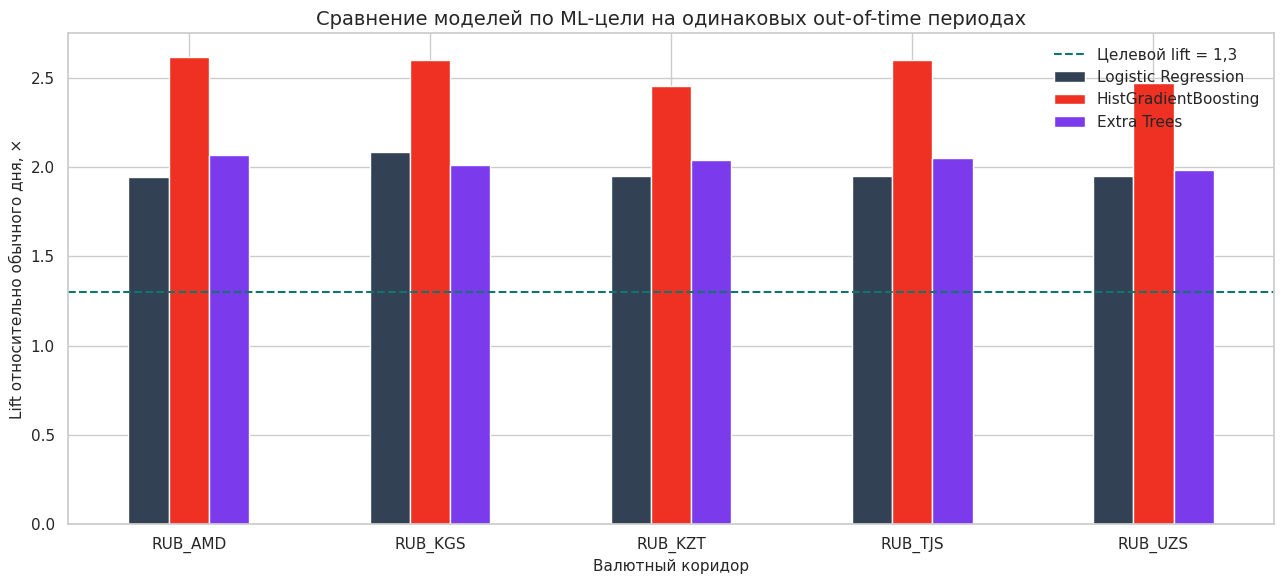

Результат по ML-цели:** HistGradientBoosting даёт lift от **2.45** до **2.62** при частоте 1.04–1.10 сигнала в неделю. Правдивость клиентского сообщения отдельно отражена в `message_lift`: 0.91–1.09.

In [45]:
plot_table = lift_table.rename(columns={
    "logistic": "Logistic Regression",
    "hist_gradient_boosting": "HistGradientBoosting",
    "extra_trees": "Extra Trees",
})
ax = plot_table.plot(kind="bar", figsize=(13, 6), color=["#334155", "#EF3124", "#7C3AED"])
ax.axhline(1.3, color="#0F766E", linestyle="--", label="Целевой lift = 1,3")
ax.set_title("Сравнение моделей по ML-цели на одинаковых out-of-time периодах")
ax.set_xlabel("Валютный коридор")
ax.set_ylabel("Lift относительно обычного дня, ×")
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

hgb = summary[summary.model == "hist_gradient_boosting"]
display(Markdown(
    f"Результат по ML-цели:** HistGradientBoosting даёт lift "
    f"от **{hgb.lift.min():.2f}** до **{hgb.lift.max():.2f}** при частоте "
    f"{hgb.signals_per_week.min():.2f}–{hgb.signals_per_week.max():.2f} сигнала в неделю. "
    f"Правдивость клиентского сообщения отдельно отражена в `message_lift`: "
    f"{hgb.message_lift.min():.2f}–{hgb.message_lift.max():.2f}."
))

### 12.1. Методический аудит: а что, если учить сразу правдивость пуша?

Высокий lift по локальному минимуму ещё не гарантирует высокий `message_lift`. Поэтому проводим дополнительный эксперимент: обучаем Logistic Regression и HistGradientBoosting напрямую на `good_now_hit`.

Это отвечает уже не на вопрос «похож ли день на локальный минимум?», а на вопрос:

> «Если написать сегодня, не появится ли в следующие пять публикаций заметно более выгодный курс?»

Если и этот вариант не достигает lift 1,3, честный вывод — дневного ряда и текущих признаков недостаточно для обещания `good_now`; тогда нужно менять текст сигнала, данные, горизонт или постановку цели.

In [46]:
forward_parts = []
for corridor, dataset in datasets.items():
    print(f"Проверяем forward-цель для {corridor}...")
    forward_parts.append(walk_forward_compare(
        dataset,
        corridor,
        target_column="good_now_hit",
        model_names=("logistic", "hist_gradient_boosting"),
    ))
forward_folds = pd.concat(forward_parts, ignore_index=True)

forward_rows = []
for (corridor, model_name), group in forward_folds.groupby(["corridor", "model"], sort=False):
    forward_rows.append({"corridor": corridor, "model": model_name, **aggregate_group(group)})
forward_summary = pd.DataFrame(forward_rows)
forward_table = forward_summary.pivot(index="corridor", columns="model", values="lift")
display(forward_table.round(3))

forward_hgb = forward_summary[forward_summary.model == "hist_gradient_boosting"]
target_passed = bool((forward_hgb.lift >= 1.3).all())
verdict = (
    "проходит целевой lift 1,3 на всех коридорах"
    if target_passed
    else "не проходит целевой lift 1,3 на всех коридорах — это честное ограничение текущего решения"
)
display(Markdown(
    f"**Результат прямого обучения на правдивость пуша:** lift "
    f"{forward_hgb.lift.min():.2f}–{forward_hgb.lift.max():.2f}; модель **{verdict}**."
))

Проверяем forward-цель для RUB_TJS...
Проверяем forward-цель для RUB_UZS...
Проверяем forward-цель для RUB_KGS...
Проверяем forward-цель для RUB_AMD...
Проверяем forward-цель для RUB_KZT...


model,hist_gradient_boosting,logistic
corridor,,
RUB_AMD,1.045,1.120
RUB_KGS,1.072,1.039
RUB_KZT,0.990,1.047
RUB_TJS,1.045,1.066
RUB_UZS,1.058,1.045


**Результат прямого обучения на правдивость пуша:** lift 0.99–1.07; модель **не проходит целевой lift 1,3 на всех коридорах — это честное ограничение текущего решения**.

## 13. Статистическое сравнение моделей

Просто увидеть более высокий столбик недостаточно. Мы парно сравниваем модели на одних и тех же временных фолдах.

Bootstrap много раз случайно пересобирает набор фолдов и считает разницу lift. Если весь 95% интервал разницы выше нуля, говорим, что кандидат статистически лучше логистики.

In [47]:
def aggregate_lift(group):
    signals = group.signals.sum()
    if not signals:
        return 0.0
    hit_rate = (group.hit_rate * group.signals).sum() / signals
    baseline = group.baseline_hit_rate.mean()
    return float(hit_rate / baseline) if baseline else 0.0


def paired_bootstrap_delta(candidate, baseline, samples=2000):
    candidate = candidate.sort_values("fold").reset_index(drop=True)
    baseline = baseline.sort_values("fold").reset_index(drop=True)
    assert candidate.fold.tolist() == baseline.fold.tolist()
    rng = np.random.default_rng(SEED)
    deltas = []
    for _ in range(samples):
        indices = rng.integers(0, len(candidate), len(candidate))
        deltas.append(
            aggregate_lift(candidate.iloc[indices]) - aggregate_lift(baseline.iloc[indices])
        )
    actual = aggregate_lift(candidate) - aggregate_lift(baseline)
    low, high = np.quantile(deltas, [0.025, 0.975])
    return actual, low, high


comparison_rows = []
for corridor in sorted(folds.corridor.unique()):
    logistic = folds[(folds.corridor == corridor) & (folds.model == "logistic")]
    for candidate_name in ("hist_gradient_boosting", "extra_trees"):
        candidate = folds[(folds.corridor == corridor) & (folds.model == candidate_name)]
        delta, low, high = paired_bootstrap_delta(candidate, logistic)
        comparison_rows.append({
            "corridor": corridor,
            "candidate": candidate_name,
            "lift_delta": delta,
            "ci_low": low,
            "ci_high": high,
            "statistically_better": low > 0,
        })
comparisons = pd.DataFrame(comparison_rows)
display(comparisons.round(3))

,corridor,candidate,lift_delta,ci_low,ci_high,statistically_better
0,RUB_AMD,hist_gradient_boosting,0.673,0.423,0.899,True
1,RUB_AMD,extra_trees,0.124,-0.118,0.360,False
2,RUB_KGS,hist_gradient_boosting,0.518,0.259,0.750,True
3,RUB_KGS,extra_trees,-0.072,-0.294,0.126,False
4,RUB_KZT,hist_gradient_boosting,0.500,0.257,0.743,True
5,RUB_KZT,extra_trees,0.090,-0.149,0.328,False
6,RUB_TJS,hist_gradient_boosting,0.653,0.392,0.926,True
7,RUB_TJS,extra_trees,0.103,-0.083,0.283,False
8,RUB_UZS,hist_gradient_boosting,0.521,0.299,0.752,True
9,RUB_UZS,extra_trees,0.031,-0.192,0.235,False


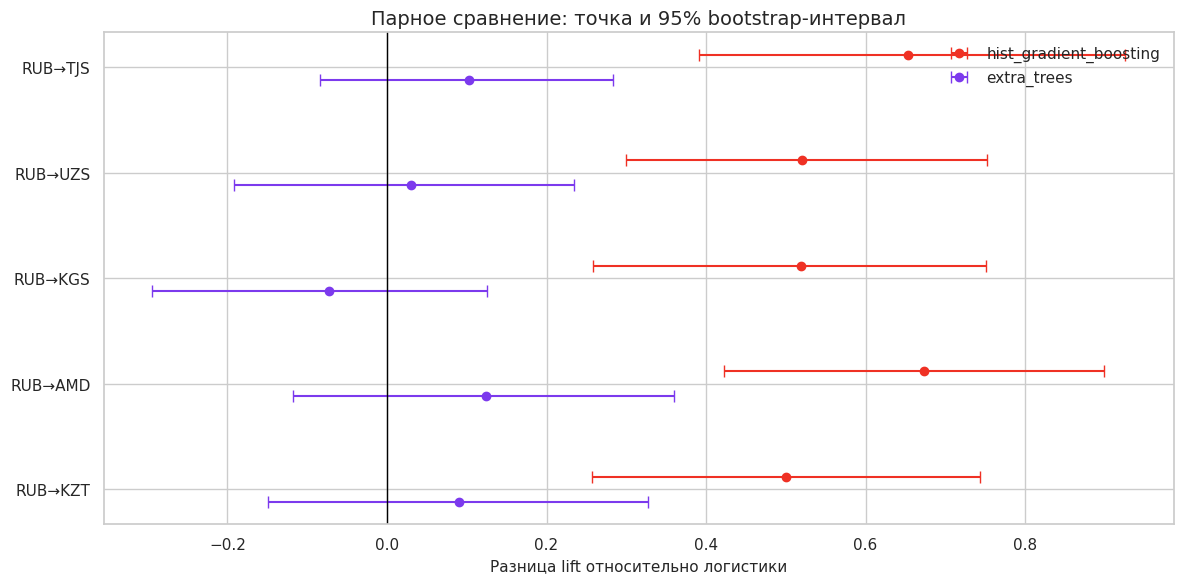

**Вывод:** у бустинга положительная нижняя граница интервала на **5 из 5** коридоров. Extra Trees оставляем исследовательским вариантом, если его интервалы пересекают ноль.

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(RECIPIENT_CURRENCIES))
for offset, candidate_name, color in [
    (-0.12, "hist_gradient_boosting", "#EF3124"),
    (0.12, "extra_trees", "#7C3AED"),
]:
    part = comparisons[comparisons.candidate == candidate_name].set_index("corridor").loc[
        [f"RUB_{currency}" for currency in RECIPIENT_CURRENCIES]
    ]
    centers = part.lift_delta.to_numpy()
    errors = np.vstack([centers - part.ci_low.to_numpy(), part.ci_high.to_numpy() - centers])
    ax.errorbar(centers, positions + offset, xerr=errors, fmt="o", capsize=4,
                color=color, label=candidate_name)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(positions, [f"RUB→{currency}" for currency in RECIPIENT_CURRENCIES])
ax.invert_yaxis()
ax.set_xlabel("Разница lift относительно логистики")
ax.set_title("Парное сравнение: точка и 95% bootstrap-интервал")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

hgb_comparison = comparisons[comparisons.candidate == "hist_gradient_boosting"]
display(Markdown(
    f"**Вывод:** у бустинга положительная нижняя граница интервала на "
    f"**{hgb_comparison.statistically_better.sum()} из {len(hgb_comparison)}** коридоров. "
    "Extra Trees оставляем исследовательским вариантом, если его интервалы пересекают ноль."
))

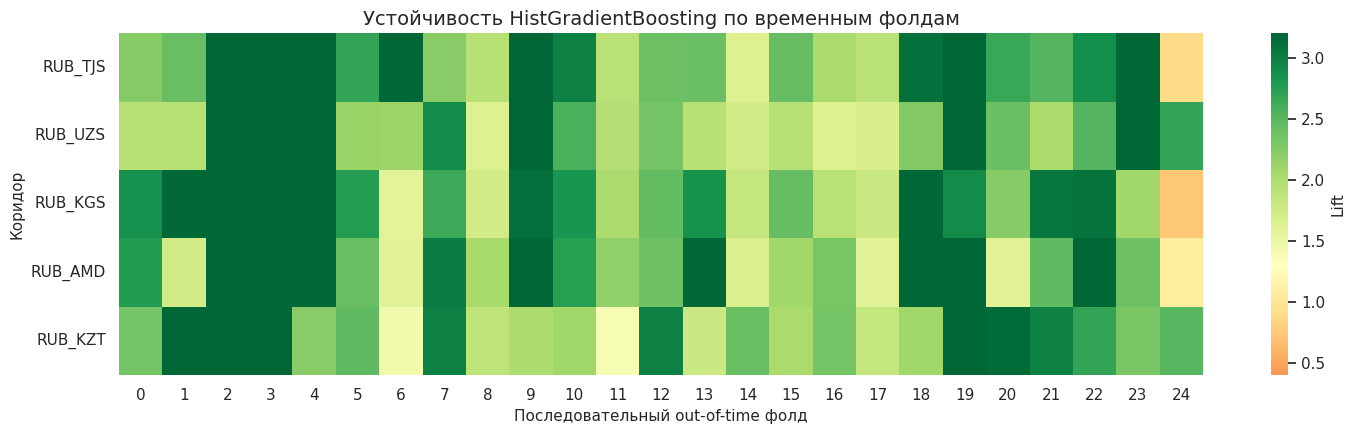

In [49]:
hgb_folds = folds[folds.model == "hist_gradient_boosting"].pivot(
    index="corridor", columns="fold", values="lift"
).reindex([f"RUB_{currency}" for currency in RECIPIENT_CURRENCIES])

plt.figure(figsize=(15, 4.5))
sns.heatmap(hgb_folds, cmap="RdYlGn", center=1.3, vmin=0.4, vmax=3.2, cbar_kws={"label": "Lift"})
plt.title("Устойчивость HistGradientBoosting по временным фолдам")
plt.xlabel("Последовательный out-of-time фолд")
plt.ylabel("Коридор")
plt.tight_layout()
plt.show()

## 14. Из вероятности делаем финальный сигнал

Финальный слой:

1. физически отрезает все данные после `as_of`;
2. на прошлом выбирает порог;
3. обучает победивший HistGradientBoosting;
4. смотрит три последние вероятности;
5. сильный сигнал помечает `fast`, пограничный ждёт второго превышения и становится `confirmed`;
6. добавляет наблюдаемый факт и локальное объяснение модели.

Локальное объяснение приблизительное: по очереди заменяем каждый признак медианой и смотрим, насколько упала вероятность. Это показывает вклад признака в расчёт, но не доказывает экономическую причинность.

In [50]:
FEATURE_LABELS = {
    "return_1_bps": "изменение за одну публикацию",
    "return_3_bps": "изменение за три публикации",
    "return_5_bps": "изменение за пять публикаций",
    "return_10_bps": "среднесрочная динамика",
    "return_20_bps": "динамика за 20 публикаций",
    "volatility_5_bps": "краткосрочная волатильность",
    "volatility_20_bps": "волатильность за 20 публикаций",
    "rank_20": "положение в диапазоне 20 публикаций",
    "rank_60": "положение в диапазоне 60 публикаций",
    "rank_120": "положение в диапазоне 120 публикаций",
    "distance_min_20_bps": "расстояние до недавнего минимума",
    "distance_min_60_bps": "расстояние до среднесрочного минимума",
    "distance_max_20_bps": "расстояние до недавнего максимума",
    "down_streak": "длина серии снижения",
    "up_streak": "длина серии роста",
    "acceleration_bps": "ускорение движения",
    "month_sin": "календарная сезонность",
    "month_cos": "календарная сезонность",
    "usd_return_1_bps": "однодневная динамика доллара",
    "usd_return_5_bps": "динамика доллара",
    "usd_return_20_bps": "среднесрочная динамика доллара",
    "usd_volatility_20_bps": "волатильность доллара",
    "eur_return_1_bps": "однодневная динамика евро",
    "eur_return_5_bps": "динамика евро",
    "eur_return_20_bps": "среднесрочная динамика евро",
    "eur_volatility_20_bps": "волатильность евро",
    "cny_return_1_bps": "однодневная динамика юаня",
    "cny_return_5_bps": "динамика юаня",
    "cny_return_20_bps": "среднесрочная динамика юаня",
    "cny_volatility_20_bps": "волатильность юаня",
    "recipient_days_to_holiday_30": "расстояние до праздника в стране получателя",
    "recipient_days_since_holiday_30": "расстояние от праздника в стране получателя",
    "recipient_preholiday_7": "близость праздника в стране получателя",
    "recipient_postholiday_3": "период после праздника в стране получателя",
    "russia_days_to_holiday_30": "расстояние до праздника в России",
    "russia_preholiday_7": "близость праздника в России",
}


def local_reasons(model, current_x, training_x, top_n=3):
    sample = np.asarray(current_x, dtype=float).reshape(1, -1)
    original_probability = model.predict_proba(sample)[0, 1]
    medians = np.median(training_x, axis=0)
    contributions = []
    for index, name in enumerate(FEATURE_NAMES):
        altered = sample.copy()
        altered[0, index] = medians[index]
        changed_probability = model.predict_proba(altered)[0, 1]
        contributions.append((original_probability - changed_probability, name))
    positive = sorted([item for item in contributions if item[0] > 0], reverse=True)
    selected = positive[:top_n] or sorted(contributions, key=lambda item: abs(item[0]), reverse=True)[:top_n]
    return [FEATURE_LABELS[name] for _, name in selected]


def signal_speed(probabilities, threshold, strong_margin=STRONG_MARGIN):
    strong_threshold = min(threshold + strong_margin, 0.95)
    if probabilities[-1] >= strong_threshold:
        return "fast"
    if probabilities[-1] >= threshold and probabilities[-2] >= threshold:
        return "confirmed"
    return None


def observable_explanation(row):
    percentile = round((1 - row.rank_60) * 100)
    if percentile >= 60:
        return f"Курс ниже, чем в {percentile}% последних 60 публикаций"
    change = row.return_5_bps / 100
    direction = "снизился" if change < 0 else "вырос"
    return f"За пять публикаций курс {direction} на {abs(change):.2f}%"


def final_signals_as_of(rates, as_of, model_name="hist_gradient_boosting"):
    as_of = pd.Timestamp(as_of)
    truncated = rates[rates.available_date <= as_of].copy()
    output = []

    for currency in RECIPIENT_CURRENCIES:
        corridor = f"RUB_{currency}"
        table = build_feature_table(truncated, corridor)
        training = table.dropna(subset=list(FEATURE_NAMES) + ["target"]).reset_index(drop=True)
        latest = table.dropna(subset=list(FEATURE_NAMES)).tail(3)
        if len(training) < 350 or len(latest) < 3:
            continue

        x = training[list(FEATURE_NAMES)].to_numpy(dtype=float)
        y = training.target.to_numpy(dtype=int)
        validation_start = len(training) - 200
        fit_end = validation_start - HORIZON

        calibration_model = build_model(model_name)
        calibration_model.fit(x[:fit_end], y[:fit_end])
        validation_probabilities = calibration_model.predict_proba(x[validation_start:])[:, 1]
        threshold = choose_threshold(
            validation_probabilities,
            y[validation_start:],
            training.available_date.iloc[validation_start:].to_numpy(),
        )

        model = build_model(model_name)
        model.fit(x, y)
        latest_x = latest[list(FEATURE_NAMES)].to_numpy(dtype=float)
        probabilities = model.predict_proba(latest_x)[:, 1]
        speed = signal_speed(probabilities, threshold)
        if speed is None:
            continue

        current = latest.iloc[-1]
        output.append({
            "date": current.available_date.date(),
            "corridor": corridor,
            "indicator": f"{model_name}_local_minimum",
            "client_meaning": "много валюты получателя за рубль",
            "strength": float(probabilities[-1]),
            "threshold": float(threshold),
            "speed": speed,
            "recommended_scenario": "good_now",
            "explanation": observable_explanation(current),
            "model_reasons": ", ".join(local_reasons(model, latest_x[-1], x)),
        })
    return pd.DataFrame(output)

In [51]:
requested_demo_date = pd.Timestamp("2026-08-21")
demo_date = requested_demo_date if requested_demo_date <= rates.available_date.max() else rates.available_date.max()
final_signals = final_signals_as_of(rates, demo_date)

display(Markdown(f"### Сигналы так, как они выглядели бы на {demo_date.date()}"))
display(final_signals)

if final_signals.empty:
    display(Markdown(
        "**пустая таблица — тоже корректный результат:** модель не обязана придумывать повод для пуша."
    ))
else:
    display(Markdown(
        f"**получили {len(final_signals)} сигналов.** Это ещё не отправленные пуши: "
        "дальше продуктовый слой применит общий клиентский лимит и приоритеты других коммуникаций."
    ))

### Сигналы так, как они выглядели бы на 2026-08-21

,date,corridor,indicator,client_meaning,strength,threshold,speed,recommended_scenario,explanation,model_reasons
0,2026-08-21,RUB_TJS,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.788866,0.1,fast,good_now,За пять публикаций курс снизился на 0.42%,"изменение за три публикации, изменение за одну..."
1,2026-08-21,RUB_KGS,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.732951,0.1,fast,good_now,За пять публикаций курс снизился на 0.54%,"среднесрочная динамика юаня, однодневная динам..."
2,2026-08-21,RUB_AMD,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.816262,0.1,fast,good_now,За пять публикаций курс снизился на 0.37%,"изменение за три публикации, изменение за одну..."
3,2026-08-21,RUB_KZT,hist_gradient_boosting_local_minimum,много валюты получателя за рубль,0.583104,0.1,fast,good_now,За пять публикаций курс вырос на 0.10%,"расстояние до недавнего максимума, изменение з..."


**получили 4 сигналов.** Это ещё не отправленные пуши: дальше продуктовый слой применит общий клиентский лимит и приоритеты других коммуникаций.

## 15. Автоматические проверки

Теперь проверяем фундамент:

- номинал нормирован;
- нет дублей и невозможных значений;
- признаки на прошлую дату не меняются, если добавить будущее;
- обучение каждого фолда заканчивается раньше теста;
- расчёт `as_of` одинаков для полного и физически обрезанного файла.

Последние две проверки особенно важны: любое заглядывание вперёд дисквалифицирует решение.

In [52]:
# 1. Базовое качество данных
assert rates.duplicated(["currency", "available_date"]).sum() == 0
assert (rates.rub_per_unit > 0).all()
assert np.allclose(rates.value_rub / rates.nominal, rates.rub_per_unit)

# 2. Достаточная историческая глубина
history_years = (rates.available_date.max() - rates.available_date.min()).days / 365.25
assert history_years >= 5

# 3. Признаки прошлого не меняются после добавления будущих строк
leakage_cutoff = pd.Timestamp("2025-06-30")
if leakage_cutoff > rates.available_date.max():
    leakage_cutoff = rates.available_date.quantile(0.85)

full_features = build_feature_table(rates, "RUB_TJS")
truncated_rates = rates[rates.available_date <= leakage_cutoff]
truncated_features = build_feature_table(truncated_rates, "RUB_TJS")

left = full_features[full_features.available_date <= leakage_cutoff].set_index("available_date")
right = truncated_features.set_index("available_date")
common_dates = left.index.intersection(right.index)
np.testing.assert_allclose(
    left.loc[common_dates, list(FEATURE_NAMES)].to_numpy(dtype=float),
    right.loc[common_dates, list(FEATURE_NAMES)].to_numpy(dtype=float),
    equal_nan=True,
)

# 4. Во всех walk-forward фолдах обучение раньше теста
assert (folds.train_end < folds.test_start).all()
assert folds.groupby(["corridor", "model"]).fold.nunique().min() >= 20

# 5. Функция as_of физически не использует строки из будущего
signals_from_full = final_signals_as_of(rates, demo_date)
signals_from_cut = final_signals_as_of(rates[rates.available_date <= demo_date], demo_date)
pd.testing.assert_frame_equal(signals_from_full, signals_from_cut)

print("✅ Все проверки пройдены: базовые данные и защита от утечки будущего работают")

✅ Все проверки пройдены: базовые данные и защита от утечки будущего работают


## 16. Финальный вывод

**собираем всю историю в одну фразу:**

```text
открытые курсы ЦБ
    → нормализация номинала
    → trailing-признаки без будущего
    → историческая разметка хороших моментов
    → walk-forward
    → сравнение трёх моделей
    → HistGradientBoosting
    → индивидуальный порог
    → fast/confirmed
    → объяснимый сигнал
```

Что важно честно сказать на защите:

1. Простые правила были первым baseline, но устойчивого преимущества не дали.
2. Бустинг лучше объединяет движение, уровень, волатильность, контекст и календарь.
3. Главная метрика — lift при рабочей частоте, а не обычная accuracy.
4. Ложный пуш дороже пропущенного момента, поэтому порог асимметричный.
5. Курс ЦБ — публичный proxy, а не фактический курс исполнения банка.
6. Исторический lift подтверждает качество сигнала, но продуктовый uplift переводов докажет только пилот с контрольной группой.
7. Нужно подтвердить у кейсодателя, является ли основной целью локальный минимум ±h или отсутствие существенно лучшего курса после пуша.
8. Если `message_lift` или прямое обучение на `good_now_hit` не достигают 1,3, нельзя выдавать высокий lift локального минимума за доказательство правдивости пуша. Это отдельный честный результат и план следующей итерации.